# Let's follow along the micrograd tutorial to gain a fundamental understanding of Neural Networks

https://www.youtube.com/watch?v=VMj-3S1tku0

In [15]:
# libraries to install
# math, numpy, matplotlib, graphviz
# pytorch to campare with our simple model
# pip install micrograd

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
def f(x):
    return 3*x**2 - 4*x +5

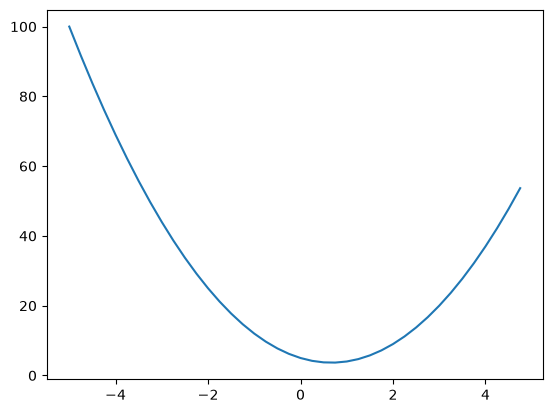

In [18]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [19]:
# analytical derivative
def f_prime(x):
    return 6*x - 4

In [20]:
x = 2/3

# numerical derivative
h = 0.000000000001
print(f(x), f(x+h))
print('numerical slope', (f(x+h)-f(x))/h)
print('analytical slope', f_prime(x))

3.666666666666667 3.6666666666666665
numerical slope -0.0004440892098500626
analytical slope 0.0


In [21]:
# a more complex case
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [22]:
# let's try to evaluate derivative of d wrt a, b, and c
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope wrt a', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope wrt a -3.000000000010772


In [23]:
# NNs are massive mathematical expressions. We need some data structure that maintain these expressions.
# Let's build out this data structure as a Value object
class Value:

    # the __init__ function basically identifies all the attributes this object contains. 
    # As we will see here, the original object will have empty attributes that gets added when an operation is applied
    def __init__(self, data, _children=(), _op='', label=''): 
        self.data = data
        
        # _children parameter identifies what feeds into generating a Value.
        self._prev = set(_children)
        # When defining Value from scratch, there are no children so it's an empty tuple

        # we now add an identifier for what operations went into generating a value
        self._op = _op
        # When defining Value from scratch, there are no operators so it's an empty str
        
        self.label = label

        # variable added to maintain derivative used in backprop
        self.grad = 0.0 # at initialization, we assume the value does not impact the output

        # manually doing self back propagation is ridiculous, so let's try to automate this a little.
        self._backward = lambda: None


    # this repr function helps print out a nice human readable output in line instead of an 'ugly' expression. Try with or without
    def __repr__(self):
        return f'Value(data={self.data})'

    # Now we would like to not justt contain values. We would like to act on the Value object, such as addition
    # we have to tell python how to do that, because operations are not yet defined for our Value object
    def __add__(self, other): # if a is self, in a+b, b is other
        other = other if isinstance(other, Value) else Value(other) # for convenience, an instance conversion for other
        out = Value(self.data + other.data, (self, other), '+')
        # Value objects used to generate a Value is stored as this generated Value's children (self, other)
        # operation used is identified as '+'
        
        # for addition operation, the grad is inherited from the parent node
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad
            # self.grad = 1.0 * out.grad 
            # other.grad = 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__(self,other):
        return self+other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # for convenience, an instance conversion for other
        out = Value(self.data * other.data, (self, other), '*')
        # for multiplication operation, the grad is derived from the chain rule, yielding:
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
            # self.grad = other.data * out.grad 
            # other.grad = self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other):
        # instance conversion in __mul__ lets Value*float work but not float*Value. 
        # __rmul__ automatically detects this type error in float*Value and swap their positions.
        # r in rmul stands for right, meaning multiplying from the right side
        return self * other

    # subtract is just adding a negative number
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    # division is just multiplying by a negative power
    # introducing a power function will help with this and more
    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'only supporting int/float powers for now'
        out = Value(self.data**other, (self,), f'**{other}')
        # remember, derivative of a power x^n = n*x^(n1-), multiplied by out.grad because of the chain rule. 
        def _backward():
            self.grad += other*(self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other): # self/other = self*other^(-1)
        return self * other**(-1)



    # one option to add tanh is to use exponents as tanh can be expressed as with exponents
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1) # exponent form of tanh
        out = Value(t, (self,), 'tanh')        
        # for tanh operation, the grad is derived as 1-tanh^2, multiplied by out.grad because of the chain rule.
        def _backward():
            self.grad += (1.0 - out.data**2) * out.grad # or self.grad += (1.0 - t**2) * out.grad
            # self.grad = (1.0 - out.data**2) * out.grad # or self.grad = (1.0 - t**2) * out.grad
        out._backward = _backward

        return out

    # define an exponential function
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        # derivative to exp is exp, so out.data, multiplied by out.grad because of the chain rule
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    # add the backward function, which automates calculating gradients starting from final value to all of its children
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                # the below loop ensures all children are added to topo before adding itself
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # to apply this, again, initialize .grad to 1.0, assuming backward is applied to final Value
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    #



a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10, label='c')
# a + b, a*b

# so now doing d=a*b+c should work. a.__mul__(b).__add__(c)
e = a*b; e.label='e'
d = e+c; d.label='d'
# d = a*b+c
# d, a.__mul__(b).__add__(c)
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

# overall, we have built out a mathematical expression using + and *. a series of Values feed into creating a final Value 'L'
# the relationship between each Value is illustrated in the graphic below

Value(data=-8.0)

In [24]:
d._prev, d._op # we see that d contains 2 values -6 and 10, and these values are added '+' to each other

({Value(data=-6.0), Value(data=10)}, '+')

In [25]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ % s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an operation node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [26]:
a = Value(1.0, label = 'a')
b = Value(-0.5, label = 'b')
c = Value(0.7, label = 'c')
d = Value(-1.2, label = 'd')
e = Value(0.0, label = 'e')
bias = Value(0.05, label='b')

f = a*b; f.label = 'f'
g = c+d+e; g.label = 'g'
h = a**2; h.label = 'h'

i = f*g; i.label = 'i'
j = h*e; j.label = 'j'

k = j-i; k.label = 'k'
l = k + bias; l.label = 'l'
o = l.tanh(); o.label = 'o'

o.grad = 1.0
o.backward()

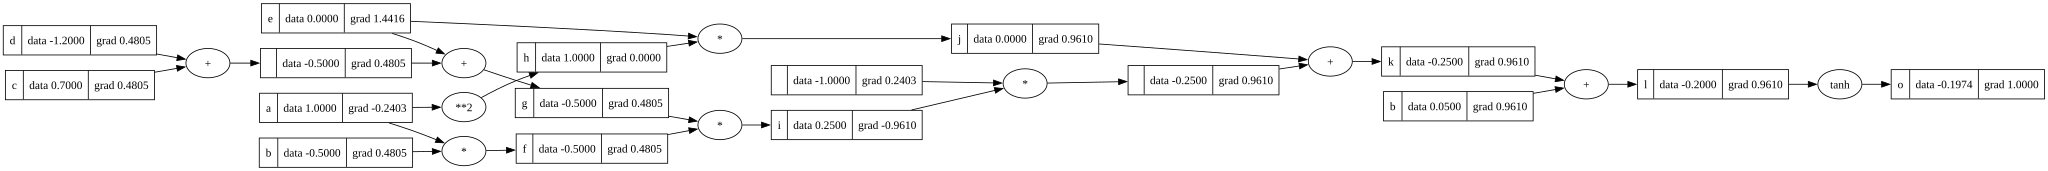

In [27]:
draw_dot(o)

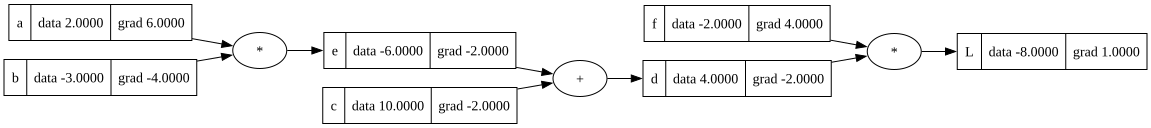

In [14]:
draw_dot(L)

In [13]:
# the output of the forward pass is -8
# Now we want to run backpropagation, and in essence we want to reverse and calculate the gradient along all the intermediate values
# and really what we are computing is dL/dL(=1), dL/df, dL/dd, dL/de, dL/dc, dL/db, dL/da
# in NN, we are interested in the derivative of the loss function 'L' with respect to the weights of the NN a,b,c,d,e,f. This tells us how the weights impact the loss function.
# in other words, derivative of output (loss function) wrt leaf nodes (weights). The leaf nodes above are a,b,c,f as e and d are dependent on these inputs.
# to do this, first we add a variable inside the Value class that maintains the derivative of L wrt the Value.


# so manually, we know dL/dL = 1
# L = d * f = 4.0 * -2.0
L.grad = 1.0
f.grad = 4.0 #dL/df
d.grad = -2.0 #dL/dd

# now what about dL/dc and dL/de
# with chain rule, we just need dL/dd * dd/dc = dL/dc, same for dL/de = dL/dd * dd/de
# dL/dd = -2.0
# d = c + e, dd/dc = 1, dd/de = 1
c.grad = -2.0 #d.grad * 1.0 # dL/dc = dL/dd * dd/dc, dd/dc is a local derivative that feeds into the global derivative dL/dc
e.grad = -2.0 #d.grad * 1.0 # dL/de = dL/dd * dd/de, dd/de is a local derivative that feeds into the global derivative dL/de 
# we can also see from here that the + operator propagates the parent grad to the children grad. grad of c and e are the exact same as grad of d

# similarly, dL/da and dL/db
# dL/de = -2.0
# e = a*b, so we need dL/de, de/da, de/db
a.grad = -2.0 * -3.0# e.grad * b.data
b.grad = -2.0 * 2.0 # e.grad * a.data


In [14]:
# 
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)



-7.286496


In [15]:
def uh():
    # we create an intermediate function to calculate gradients so we don't pollute the global variables.
    # this is also a very useful way of doing an inline gradient check. add h to the relevant Values to check if the gradients match our analytical solution above
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L2 = L.data

    print((L2-L1)/h)

uh()

-4.000000000008441


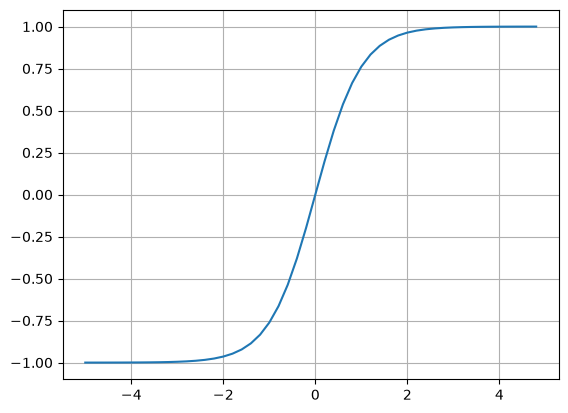

In [16]:
# neurons are a little more complex than simple operators. They contain a bias (how activatable a neuron is) and a squashing function

# here is an examble of an activation function for a neuron
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [17]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron, how 'activatable' a neuron is in a NN
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o' # we need to add tanh to the Value class

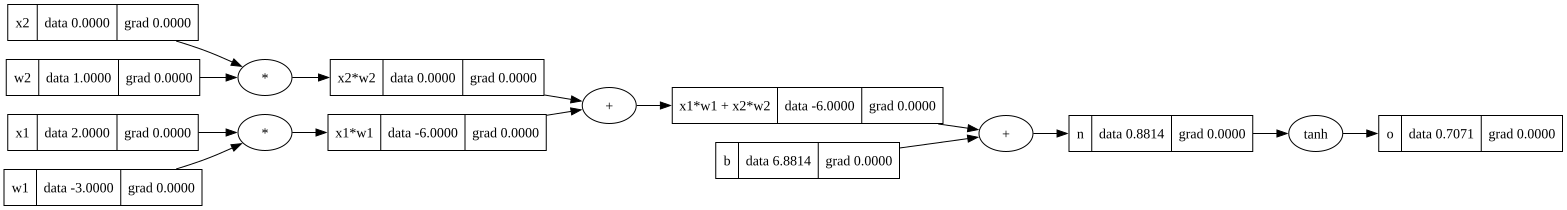

In [18]:
draw_dot(o)

In [19]:
o.grad = 1.0

# o = tanh(n)
# do/dn = 1 - tanh(n)**2 (derivation done analytically for us by mathematicians)
n.grad = 0.5 # 1-o.data**2

# recall a '+' just distributes the gradient back to the children noded
x1w1x2w2.grad = 0.5 # n.grad
b.grad = 0.5 # n.grad
# and
x1w1.grad = 0.5 # x1w1x2w2.grad
x2w2.grad = 0.5 # x1w1x2w2.grad

# chain rule time!
# x2w2 = x2*w2
# do/dx2 = d0/dx2w2 * dx2w2/dx2, 
x2.grad = x2w2.grad * w2.data
# do/dw2 = d0/dx2w2 * dx2w2/dw2, 
w2.grad = x2w2.grad * x2.data

# x1w1 = x1*w1
# do/dx1 = d0/dx1w1 * dx1w1/dx1, 
x1.grad = x1w1.grad * w1.data
# do/dw1 = d0/dx2w2 * dx2w2/dw1, 
w1.grad = x1w1.grad * x1.data


In [20]:
# we can assign grad manually, but that is not efficient. 
# We can improve this by adding a grad calculator, _backward(), to each operator in the Value class 
    # in the Value class above, o.grad is initialized to 0. But we know the grad of the loss function is supposed to be 1
    # so in the base case, we still need to initialize o.grad = 1.0
o.grad = 1.0

print('grad o =', o.grad) #self initialized
o._backward(); print('grad n=', n.grad) # n.grad is populated by o._backward
# NOTE that because the _backward() function is applied the self instead of out, it will add to the Value 'n' instead of 'o' because o = n.tanh()
# similarly, n._backward will populate grad for their children: x1w1x2w2 + b
n._backward(); print('grad x1w1x2w2 = ', x1w1x2w2.grad, '; grad b =', b.grad)

# let's do the same for all Values
x1w1x2w2._backward(); print('grad x1w1 = ', x1w1.grad, '; grad x2w2 =', x2w2.grad)
b._backward()
x1w1._backward(); print('grad x1 = ', x1.grad, '; grad w1 =', w1.grad)
x2w2._backward(); print('grad x2 = ', x2.grad, '; grad w2 =', w2.grad)
x1._backward()
w1._backward()
x2._backward()
w2._backward()

# here we apply the _backward function manually, but can we loop it through the NN automatically?

grad o = 1.0
grad n= 0.9999999999999999
grad x1w1x2w2 =  1.5 ; grad b = 1.5
grad x1w1 =  2.0 ; grad x2w2 = 2.0
grad x1 =  -7.5 ; grad w1 = 5.0
grad x2 =  2.5 ; grad w2 = 0.0


In [21]:
# let's set up a loop that applies the _backward function automatically, starting from our final loss 'o'
# we can do this using a topological sort, and take advantage of the assigned children labels to the each Value
    # in essence, topological sort lays out a complex graph in a way that information flows in one direction, i.e. left to right
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        # the below loop ensures all children are added to topo before adding itself
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

# to apply this, again, initialize o.grad
o.grad = 1.0
for node in reversed(topo):
    node._backward()

# try this and see that it works. Spoiler, it does, so we will add this into the Value class as a function so that we don't have to 
# have all this code lying around. Let's add the backward() function (without underscore) to the Values class

o.backward()


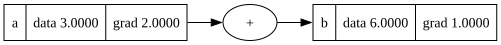

In [22]:
# However, there is a bug in this example. This bug surfaces when one node is used more than once.
# the bug is not visible at this point because our example used each node only once. Below we show the bug:

a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()

draw_dot(b)

# note that the analytical solution for db/da is 2, not 1.
# this happens because the result from other overwrites self in the Value class and 
# did not take into account that the same node is used twice

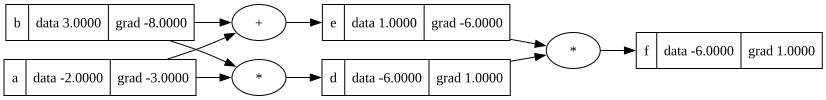

In [23]:
# another example:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()
draw_dot(f)

# the solution is to accumulate the gradients instead of assigning. = -> += (multivariable calculus)
# NOTE since the Value class is edited live, the bug may have been fixed if the notebook is run as is because the grads have been fixed.
    # to visualize the bug, change the += -> =

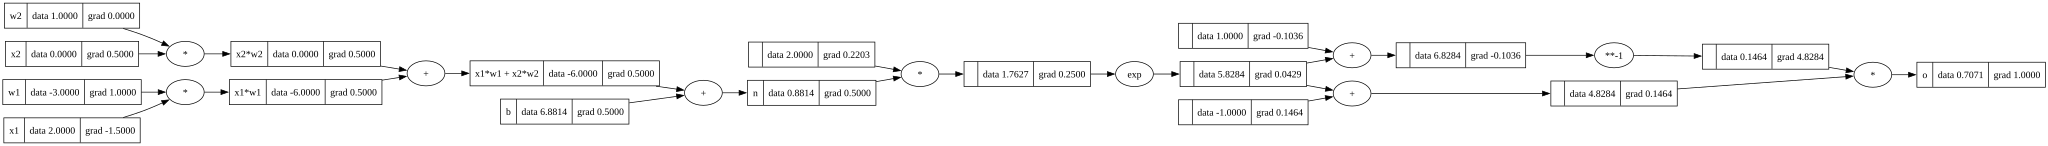

In [ ]:
# after this, we added functionalities to perform subtraction, division, exponents, and allowing floats to interact directly with a Value object.
# we took advantage of the fact that subtraction and division are special cases of addition and multiplication respectively.
# Now let's try using the exponent form of tanh instead of using tanh directly.

# copied from above
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron, how 'activatable' a neuron is in a NN
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o' # we need to add tanh to the Value class
# --- define tanh in terms of exponents. exponent implemented in Value as .exp()
e = (2*n).exp()
o = (e-1) / (e+1) # this is tanh in terms of exp()
o.label = 'o'
# --- define tanh in terms of exponents. exponent implemented in Value as .exp()
o.backward()
draw_dot(o)

In [ ]:
# packages like pytorch are typically used for trainig NNs, and they use tensors instead of scalars

In [29]:
import torch

In [32]:
torch.Tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]]).double()

tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64)

In [35]:

# inputs x1, x2
x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True # typically gradients are not calculated for leaf nodes for efficiency, but we want them here to compare
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
# weights w1, w2
w1 = torch.Tensor([-3]).double()                ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
# bias of the neuron, how 'activatable' a neuron is in a NN
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
# x1*w1 + x2*w2 + b
n = x1*w1 + x2*w2 + b

o = torch.tanh(n) # tanh squashing
print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


In [36]:
x1.grad

tensor([-1.5000], dtype=torch.float64)

# Now let's try to build NNs

In [88]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # w * x + b
        
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

# A layer is just a list of neurons
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] # A layer is just a list of neurons
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs # single element list returns just the value for pretty's sake

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()] # single line of below block
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return self.w + [self.b]

# MLP: multi layer perceptron
class MLP:
    def __init__(self, nin, nouts): # nouts is a list of number of neurons in each layer, nouts = [nout1, nout2, nout3, ...]
        sz = [nin] + nouts # this gives us a full list of number of neurons in every layer, input(nin) -> layer 1 -> layer 2 -> ...
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [214]:
x = [2.0, 3.0, -1.0]
# n = Neuron(2)
# n = Layer(2,3)
n = MLP(3, [4,4,1])
n(x) # outputs 1 value because we have 1 output node

# draw_dot(n(x))
# from above we constructed a NN with layers: 3,4,4,1
# micrograd will allow us to backpropagate through all of the Values

Value(data=0.49438163060711576)

In [215]:
# n.parameters()

In [216]:
# Now let's create a very simple example dataset. This dataset has 4 possible inputs and 4 targets associated with each input
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [217]:
# let's try some predictions using our NN above
ypred = [n(x) for x in xs]
ypred
# we see that the NN does poorly, and we can help the NN by defining a loss function
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) # here we sum the squared deviation of each input to get the MSE
loss

Value(data=6.100698898297449)

In [ ]:
max_steps = 1000
step_size = 1

k = 0
ypreds = []
while all([loss.data > 1e-5, k < max_steps]):
    #forward pass
    ypred = [n(x) for x in xs]
    # calculate loss (error)
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)])
    # back propagate gradients
    for p in n.parameters(): # reset all grad to 0 so we don't carry the previous grad over (because we used += to accumulate grads)
        p.grad = 0
    loss.backward()
    #correct data based on gradient
    for p in n.parameters():
        p.data += -step_size * p.grad

    ypreds.append(ypred)
    print(k, loss.data)
    
    k += 1



0 6.100698898297449
1 2.3675245324476064
2 7.983440737778416
3 7.971286904036315
4 7.936633562080692
5 7.73132509681076
6 0.37881114535499943
7 0.023131856445084302
8 0.0010539879356173333
9 0.0008950327066626593
10 0.0007766001592918804
11 0.0006849199149987144
12 0.0006118553793570497
13 0.000552277047427112
14 0.0005027856063987422
15 0.0004610369308036345
16 0.00042536114032601206
17 0.00039453599475044825
18 0.00036764612099966516
19 0.00034399231671980104
20 0.00032303127317084027
21 0.00030433442553449936
22 0.0002875591953117026
23 0.0002724284739313204
24 0.0002587157151018914
25 0.00024623392355809393
26 0.00023482740092014602
27 0.00022436547514279964
28 0.000214737678667047
29 0.00020584999921093288
30 0.00019762193476620212
31 0.00018998415851942827
32 0.00018287665128071968
33 0.0001762471957874864
34 0.0001700501536767367
35 0.00016424546513169307
36 0.00015879782533069942
37 0.00015367600231580285
38 0.000148852268763404
39 0.00014430192609138029
40 0.000140002903878301

In [219]:
ypreds[0], ypreds[-1]

([Value(data=0.49438163060711576),
  Value(data=0.6191115818013452),
  Value(data=0.7342710657951936),
  Value(data=0.5354243669193571)],
 [Value(data=0.999987816633558),
  Value(data=-0.9993630551359932),
  Value(data=-0.9969073892364834),
  Value(data=0.9999876781582907)])

In [ ]:
# let's try some predictions using our NN above

#this is the forward pass
ypred = [n(x) for x in xs]
ypred
# we see that the NN does poorly, and we can help the NN by defining a loss function
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) # here we sum the squared deviation of each input to get the MSE
loss

Value(data=2.0134423900375153e-05)

In [ ]:
# backward propagation
loss.backward()

In [ ]:
# now we want to nudge the parameters based on the gradients to improve the NN's predictive capability
# this is typically done by multiplying the gradient by a step size
# NOTE the way we designed this, the gradient points towards increasing loss instead of decreasing it. so we multiply by a negative step size to decrease loss
for p in n.parameters():
    p.data += -0.1 * p.grad

In [143]:
ypred

[Value(data=0.9996180915314942),
 Value(data=-0.9956449093933607),
 Value(data=-0.9994030935733692),
 Value(data=0.9991842436957843)]

In [105]:
n.layers[0].neurons[0].w[0].grad

2.1546849849982257

In [106]:
n.layers[0].neurons[0].w[0].data

-0.7243218563166642